## Problem 12.1 - Handwritten Digit Classification

In [8]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Load Data

In [1]:
# load the handwritten digits dataset
import urllib.request
import gzip
import shutil
import pandas as pd
urllib.request.urlretrieve("https://hastie.su.domains/ElemStatLearn/datasets/zip.train.gz", filename = './digits_train')
urllib.request.urlretrieve("https://hastie.su.domains/ElemStatLearn/datasets/zip.test.gz", filename = './digits_test')
with gzip.open('digits_train', 'rb') as f_in:
    with open('digits_train.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
        
with gzip.open('digits_test', 'rb') as f_in:
    with open('digits_test.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)  
        
# Load into data frame
data_train = pd.read_csv('digits_train.txt', header = None, delimiter = ' ')
data_test = pd.read_csv('digits_test.txt', header = None, delimiter = ' ')

# Extract features x and labels y
x_train = data_train.iloc[:, 1:-1].values # Training data has one column of NaN entries
y_train = data_train.iloc[:, 0].values

x_test = data_test.iloc[:, 1:].values
y_test = data_test.iloc[:, 0].values 

In [2]:
# choose device such that we can train on GPU if available
import torch
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

In [3]:
# initialize data as torch tensors 
X_train = torch.from_numpy(x_train.reshape(x_train.shape[0], 1, 16, 16)).float().to(device)
Y_train = torch.from_numpy(y_train.reshape(x_train.shape[0])).long().to(device)

### 2. Create and train a convolutional neural network

In [4]:
# define the architecture of the neural network
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()                 # initialize the nn.Module which is the parent class of this CNN
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels = 1,                    # one input i.e. a grayscale image of a digit
                out_channels = 16,                  # number of feature maps
                kernel_size = 5,                    # size of the kernel/filter
                stride = 1,                         # filter movement/step size
                padding = 2,                        # add 2 pixels of zero padding to each side
            ),                                      # output size after this layer: (16, 16, 16)
            nn.ReLU(),                              # apply the ReLU activation function
            nn.MaxPool2d(kernel_size = 2),          # downsample the feature maps by a factor of 2 (reduces height and width by factor 2: 16x16 -> 8x8) -> output size: (16, 8, 8)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),             # second conv layer: in_channels = 16 (from previous layer), out_channels = 32 feature maps -> output size: (32, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2),                        # downsample by factor of 2 again: 8x8 -> 4x4 -> output size: (32, 4, 4)
        )
        self.out = nn.Linear(32 * 4 * 4, 10)        # fully connected layer (32 feature maps of size 4x4 flattened to a vector of length 32*4*4), output size is 10 (number of classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)                   # flatten the output of conv2
        output = self.out(x)
        return output
    
# create an instance of the neural network
cnn = CNN().to(device)

In [5]:
# define a loss function and optimizer for training the cnn
loss_func = nn.CrossEntropyLoss()
pars = cnn.parameters()
optimizer = torch.optim.SGD(pars, lr = 0.05, weight_decay = 0, momentum = 0.9)

In [6]:
# train the model 
cnn.train()
n_epochs = 500
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    outputs = cnn(X_train)
    loss = loss_func(outputs, Y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

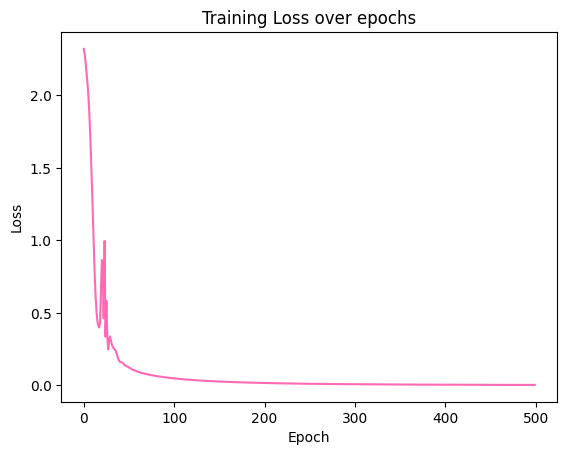

In [9]:
plt.figure()
plt.plot(losses, color = 'hotpink')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over epochs")
plt.show()

### 3. Experiment with different Architectures

Now we want to simplify this architecture by decreasing the number of convolution layers.

In [10]:
# experiment with the architecture by making it simpler 

class CNN_simplified(nn.Module):
    def __init__(self):
        super(CNN_simplified, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels = 1,
                out_channels = 8,
                kernel_size = 5,
                stride = 1,
                padding = 2,
            ),                                      # output size: (8, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2),          # output size: (8, 8, 8)
        )
        self.out = nn.Linear(8 * 8 * 8, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = x.view(x.size(0), -1)                   # flatten the output of conv1
        output = self.out(x)
        return output
    
cnn_simplified = CNN_simplified().to(device)

In [11]:
loss_func = nn.CrossEntropyLoss()
pars_simple = cnn_simplified.parameters()
optimizer_simple = torch.optim.SGD(pars_simple, lr = 0.05, weight_decay = 0, momentum = 0.9)

In [12]:
# train simple model
cnn_simplified.train()
losses_simple = []

for epoch in range(n_epochs):
    optimizer_simple.zero_grad()
    outputs = cnn_simplified(X_train)
    loss = loss_func(outputs, Y_train)
    loss.backward()
    optimizer_simple.step()
    losses_simple.append(loss.item())

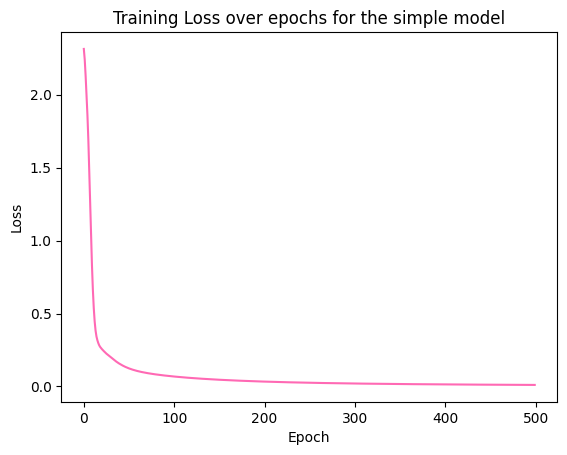

In [13]:
plt.figure()
plt.plot(losses_simple, color = 'hotpink')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over epochs for the simple model")
plt.show()

Next we do the opposite, i.e. create a more complex architecture.

In [14]:
# create a more complex version of the CNN architecture
class CNN_complex(nn.Module):
    def __init__(self):
        super(CNN_complex, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels = 1,
                out_channels = 32,
                kernel_size = 3,
                stride = 1,
                padding = 1,
            ),                                      # output size: (32, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2),          # output size: (32, 8, 8)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1),             # output size: (64, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2),                        # output size: (64, 4, 4)  
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1),            # output size: (128, 4, 4)
            nn.ReLU(),
            nn.MaxPool2d(2),                        # output size: (128, 2, 2)
        )
        self.out = nn.Linear(128 * 2 * 2, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)                   # flatten the output of conv3
        output = self.out(x)
        return output
    
cnn_complex = CNN_complex().to(device)

In [15]:
loss_func = nn.CrossEntropyLoss()
pars_complex = cnn_complex.parameters()
optimizer_complex = torch.optim.SGD(pars_complex, lr = 0.05, weight_decay = 0, momentum = 0.9)

In [46]:
# train complex model
cnn_complex.train()
losses_complex = []

for epoch in range(n_epochs):
    optimizer_complex.zero_grad()
    outputs = cnn_complex(X_train)
    loss = loss_func(outputs, Y_train)
    loss.backward()
    optimizer_complex.step()
    losses_complex.append(loss.item())

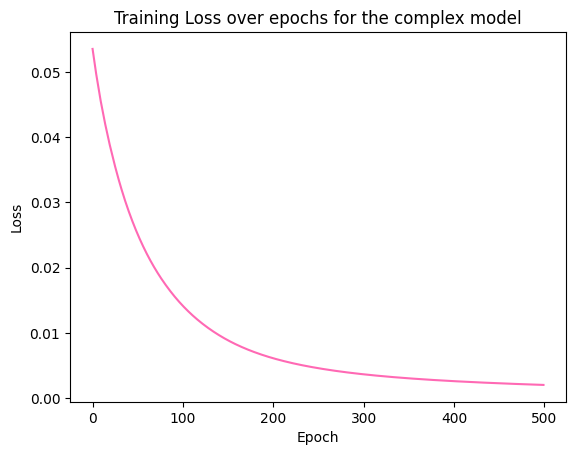

In [47]:
plt.figure()
plt.plot(losses_complex, color = 'hotpink')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over epochs for the complex model")
plt.show()

### 4. Evaluate the different models

In [30]:
# create tensor for the test data
X_test = torch.from_numpy(x_test.reshape(x_test.shape[0], 1, 16, 16)).float().to(device)
Y_test = torch.from_numpy(y_test).long().to(device)

In [17]:
# switch to evaluation model and test the model
cnn.eval()

with torch.no_grad():
    outputs = cnn(X_test)
    probabilities = torch.softmax(outputs, dim = 1)
    predictions = torch.argmax(probabilities, dim = 1)

accuracy = (predictions == y_test).float().mean().item()
print(f"Test Accuracy of the CNN: {accuracy * 100:.2f} %")

Test Accuracy of the CNN: 95.62 %


In [ ]:
# evaluate the simple model
cnn_simplified.eval()

with torch.no_grad():
    outputs = cnn_simplified(X_test)
    probabilities = torch.softmax(outputs, dim = 1)
    predictions = torch.argmax(probabilities, dim = 1)

accuracy = (predictions == y_test).float().mean().item()
print(f"Test Accuracy of the simplified CNN: {accuracy * 100:.2f} %")

Test Accuracy of the simplified CNN: 95.02 %


In [ ]:
# evaluate the more complex model
cnn_complex.eval()

with torch.no_grad():
    outputs = cnn_complex(X_test)
    probabilities = torch.softmax(outputs, dim = 1)
    predictions = torch.argmax(probabilities, dim = 1)

accuracy = (predictions == y_test).float().mean().item()
print(f"Test Accuracy of the complex CNN: {accuracy * 100:.2f} %")

Test Accuracy of the complex CNN: 95.76 %


**Observations:**  
The accuracies do not change by much for each CNN-Architecture.

### 5. Experiment with different values for Optimizer

Here we take the original cnn-architecture and experiment with different values for the SDG. SDG implements a stochastic gradient descent (with momentum). 
In this case it takes as arguments:  
- the parameters of our CNN (we cannot change much about those)
- learning rate: stepsize for each update in the gradient descent
- weight decay: penalized large weights (default: decay = 0 i.e. no regularization)
- momentum: physical inertia -> only m% is used for updating weights, the other 100-m% are neglected

In [56]:
def train_test_cnn(lr, weight_decay, momentum):
    cnn = CNN().to(device)
    loss_func = nn.CrossEntropyLoss()
    pars = cnn.parameters()
    optimizer = torch.optim.SGD(pars, lr = lr, weight_decay = weight_decay, momentum = momentum)
    cnn.train()
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        outputs = cnn(X_train)
        loss = loss_func(outputs, Y_train)
        loss.backward()
        optimizer.step()
    cnn.eval()
    with torch.no_grad():
        outputs = cnn(X_test)
        probabilities = torch.softmax(outputs, dim = 1)
        predictions = torch.argmax(probabilities, dim = 1)
    accuracy = (predictions == y_test).float().mean().item()
    return accuracy

In [ ]:
# define different values for the optimizer andf compare accuracies
learning_rates = [0.01, 0.05, 0.1]
weight_decays = [0, 0.0001, 0.001]
momenta = [0.8, 0.9, 0.99]
results = []
for lr in learning_rates:
    for wd in weight_decays:
        for m in momenta:
            acc = train_test_cnn(lr, wd, m)
            results.append((lr, wd, m, acc))
            print(f"LR: {lr}, WD: {wd}, Momentum: {m} => Test Accuracy: {acc * 100:.2f} %")


LR: 0.01, WD: 0, Momentum: 0.8 => Test Accuracy: 94.12 %
LR: 0.01, WD: 0, Momentum: 0.9 => Test Accuracy: 94.82 %
LR: 0.01, WD: 0, Momentum: 0.99 => Test Accuracy: 96.11 %
LR: 0.01, WD: 0.0001, Momentum: 0.8 => Test Accuracy: 94.32 %
LR: 0.01, WD: 0.0001, Momentum: 0.9 => Test Accuracy: 95.02 %
LR: 0.01, WD: 0.0001, Momentum: 0.99 => Test Accuracy: 95.42 %
LR: 0.01, WD: 0.001, Momentum: 0.8 => Test Accuracy: 94.12 %
LR: 0.01, WD: 0.001, Momentum: 0.9 => Test Accuracy: 95.12 %
LR: 0.01, WD: 0.001, Momentum: 0.99 => Test Accuracy: 96.06 %
LR: 0.05, WD: 0, Momentum: 0.8 => Test Accuracy: 95.17 %
LR: 0.05, WD: 0, Momentum: 0.9 => Test Accuracy: 95.52 %
LR: 0.05, WD: 0, Momentum: 0.99 => Test Accuracy: 94.67 %
LR: 0.05, WD: 0.0001, Momentum: 0.8 => Test Accuracy: 95.32 %
LR: 0.05, WD: 0.0001, Momentum: 0.9 => Test Accuracy: 95.81 %
LR: 0.05, WD: 0.0001, Momentum: 0.99 => Test Accuracy: 95.62 %
LR: 0.05, WD: 0.001, Momentum: 0.8 => Test Accuracy: 95.47 %
LR: 0.05, WD: 0.001, Momentum: 0.9 =>

In [ ]:
# display results in a table
import pandas as pd
results_df = pd.DataFrame(results, columns = ['Learning Rate', 'Weight Decay', 'Momentum', 'Test Accuracy'])
print(results_df)

    Learning Rate  Weight Decay  Momentum  Test Accuracy
0            0.01        0.0000      0.80       0.941206
1            0.01        0.0000      0.90       0.948181
2            0.01        0.0000      0.99       0.961136
3            0.01        0.0001      0.80       0.943199
4            0.01        0.0001      0.90       0.950174
5            0.01        0.0001      0.99       0.954160
6            0.01        0.0010      0.80       0.941206
7            0.01        0.0010      0.90       0.951171
8            0.01        0.0010      0.99       0.960638
9            0.05        0.0000      0.80       0.951669
10           0.05        0.0000      0.90       0.955157
11           0.05        0.0000      0.99       0.946687
12           0.05        0.0001      0.80       0.953164
13           0.05        0.0001      0.90       0.958147
14           0.05        0.0001      0.99       0.956153
15           0.05        0.0010      0.80       0.954659
16           0.05        0.0010

**Observations:**  
We get the most accurate models for this specific classification task by using a high value for momentum.  
For the weight decay we do not see a specific pattern.  
As for learning rate 0.05 seems like a good choice for this model.  


### 6. Plot some ddigits and their label pprobabilities

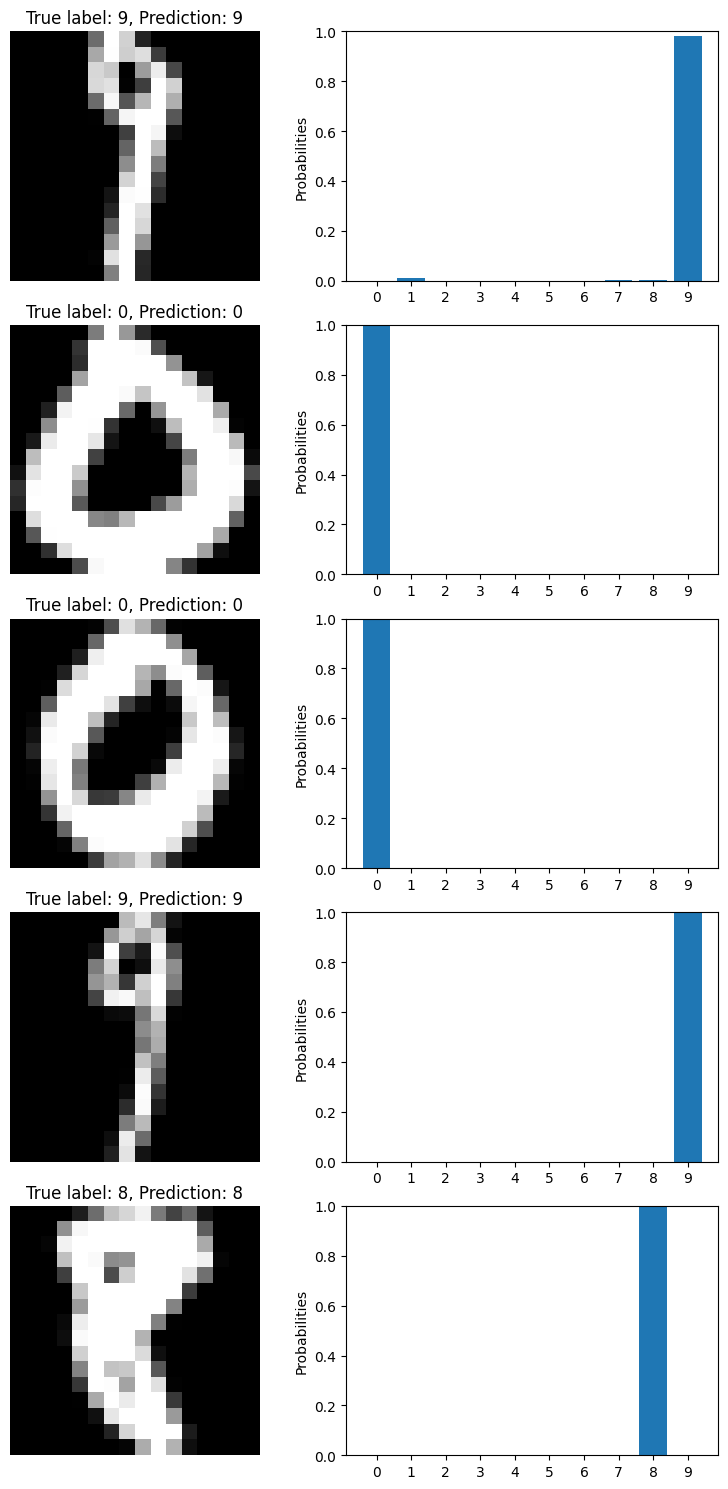

In [ ]:
n_examples = 5
indices = np.random.choice(len(X_test), n_examples, replace = False)

cnn.eval()
with torch.no_grad():
    outputs = cnn(X_test[indices])
    prob_ex = torch.softmax(outputs, dim = 1)
    pred_ex = torch.argmax(prob_ex, dim = 1)
    true_labels = y_test[indices]

fig, axes = plt.subplots(n_examples, 2, figsize = (8, 3 * n_examples))

for i in range(n_examples):
    axes[i, 0].imshow(X_test[indices[i]].cpu().squeeze(), cmap = "gray")
    axes[i, 0].set_title(f"True label: {true_labels[i]}, Prediction: {pred_ex[i]}")
    axes[i, 0].axis("off")

    axes[i, 1].bar(range(10), prob_ex[i])
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xticks(range(10))
    axes[i, 1].set_ylabel("Probabilities")

plt.tight_layout()
plt.show()


### 7. (OPTIONAL) Adversial Attacks

Now the model is tested for robustness by implementing an adversial attack, following this tutorial: https://docs.pytorch.org/tutorials/beginner/fgsm_tutorial.html. The given code was adapted so it fits the previosuly defined data and architecture. 

In [ ]:
# define the epsilos for perturbation and set a random seed for reproducability
epsilons = [0, .05, .1, .15, .2, .25, .3]
torch.manual_seed(42)

In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient (+1 or -1)
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon * sign_data_grad
    # Adding clipping to maintain [0,1] range -> avoids invalid pixel values after the attack
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    # Return the perturbed image
    return perturbed_image

In [ ]:
# function that tests the model's performance under FGSM attack
def test_fgsm(model, X, Y, epsilon):

    # define an accuracy counter anda list to hold selected examples for later visualization 
    correct = 0
    adv_examples = []

    # set the model in evaluation mode
    model.eval()

    # Loop over all examples in test set
    for i in range(X.shape[0]):

        # Select one image from the test set, create a copy, remove any previous gradient information and send to device
        data = X[i:i+1].clone().detach().to(device)
        # Get the correct label for the image and send to device
        target = Y[i:i+1].to(device)
        
        # specifies to compute the gradients with respect to the input data (essential for the attack, since we want to perturb the input image and not the model parameters)
        data.requires_grad = True

        # Forward pass the data through the model and predict class scores
        output = model(data)
        init_pred = output.argmax(dim = 1) # get the index of the max log-probability

        # If the initial prediction is wrong, don't bother attacking, just move on (FGSM targets correct classifications)
        if init_pred.item() != target.item():
            continue

        # Calculate the loss
        loss = loss_func(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass (as above)
        loss.backward()

        # extraxts the gradients of the loss with respect to the input data
        data_grad = data.grad.data

        # apply FGSM attack to the image
        perturbed_data = fgsm_attack(data, epsilon, data_grad)

        # Re-classify the now perturbed image 
        output = model(perturbed_data)

        # Check for success
        final_pred = output.argmax(dim = 1) # get the index of the max log-probability
        # if the final prediction is correct -> successful defense against the attack
        if final_pred.item() == target.item():
            correct += 1
        else:
            # Save some adv examples for visualization later where the attack was successful
            if len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )

    # Calculate final accuracy for this epsilon under FGSM attack
    final_acc = correct/X.shape[0]
    print(f"Epsilon: {epsilon}\tTest Accuracy = {final_acc * 100:.2f}%")

    # Return the accuracy and adversarial examples
    return final_acc, adv_examples

In [40]:
accuracies = []
examples = []

# Run test for each epsilon
for eps in epsilons:
    acc, ex = test_fgsm(cnn, X_test, Y_test, eps)
    accuracies.append(acc)
    examples.append(ex)

Epsilon: 0	Test Accuracy = 86.95%
Epsilon: 0.05	Test Accuracy = 83.21%
Epsilon: 0.1	Test Accuracy = 77.78%
Epsilon: 0.15	Test Accuracy = 70.75%
Epsilon: 0.2	Test Accuracy = 62.98%
Epsilon: 0.25	Test Accuracy = 54.16%
Epsilon: 0.3	Test Accuracy = 46.34%


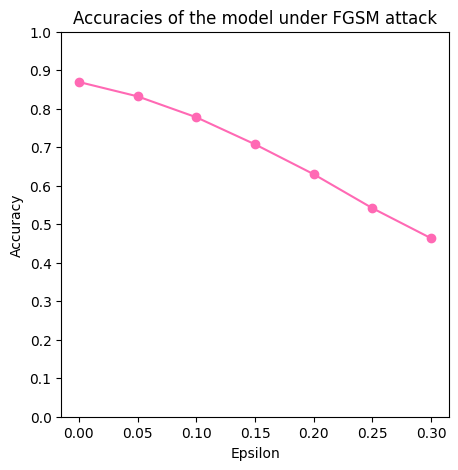

In [43]:
# plot the accuracies vs epsilon
plt.figure(figsize=(5,5))
plt.plot(epsilons, accuracies, "o-", color = 'hotpink')
plt.yticks(np.arange(0, 1.1, step = 0.1))
plt.xticks(np.arange(0, .35, step = 0.05))
plt.title("Accuracies of the model under FGSM attack")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.show()

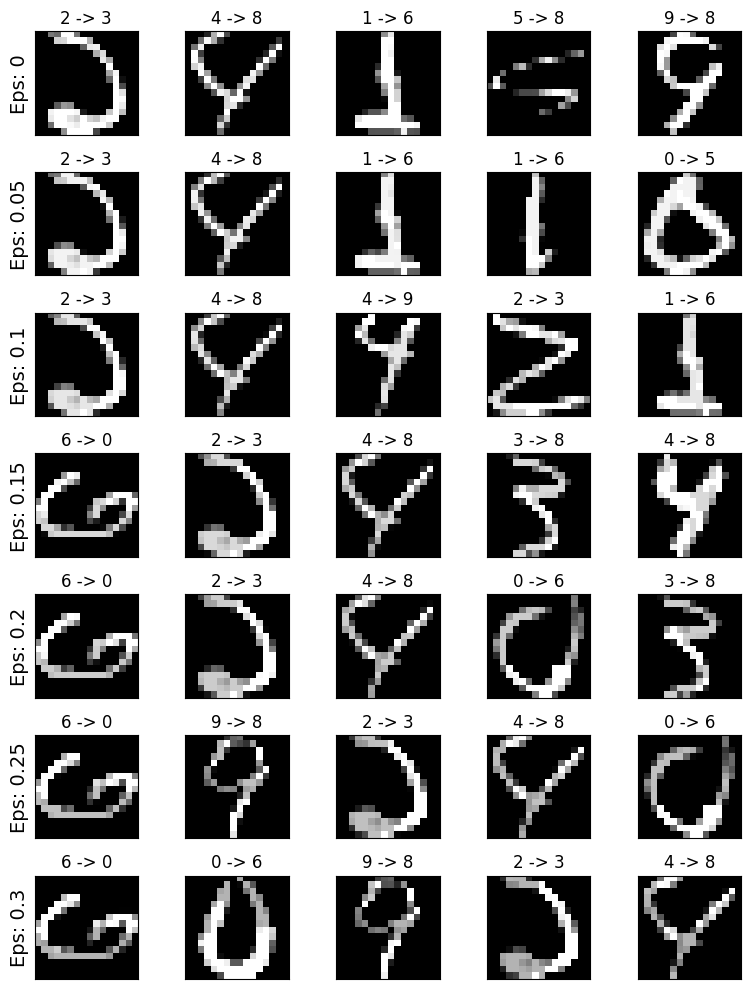

In [44]:
# show some examples of adversarial samples at each epsilon (copied from source: https://pytorch.org/tutorials/beginner/fgsm_tutorial.html)
cnt = 0
plt.figure(figsize = (8,10))
for i in range(len(epsilons)):
    for j in range(len(examples[i])):
        cnt += 1
        plt.subplot(len(epsilons),len(examples[0]),cnt)
        plt.xticks([], [])
        plt.yticks([], [])
        if j == 0:
            plt.ylabel(f"Eps: {epsilons[i]}", fontsize=14)
        orig,adv,ex = examples[i][j]
        plt.title(f"{orig} -> {adv}")
        plt.imshow(ex, cmap="gray")
plt.tight_layout()
plt.show()